In [2]:
import json
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
with open('../data/processed_lyrical_themes.llm.json', 'r') as f:
    data = json.load(f)

In [4]:
df = pd.json_normalize(data)

lines_per_album = (
    df.groupby(['album_code', 'album'])['n_lyrics']
    .sum()
    .reset_index(name='n_lines')
    .sort_values('album_code')
)

print(lines_per_album.to_string(index=False))

album_code                         album  n_lines
       EVE                      Evermore      910
       FER                      Fearless     1102
       FOL                      Folklore      720
       LSG        The Life Of A Showgirl      628
       LVR                         Lover      922
       MID                     Midnights     1071
       NEN                          1989     1218
       OTH                   Other Songs       85
       RED                           Red     1431
       REP                    Reputation      941
       SPN                     Speak Now     1132
       TPD The Tortured Poets Department     1547
       TSW                  Taylor Swift      563


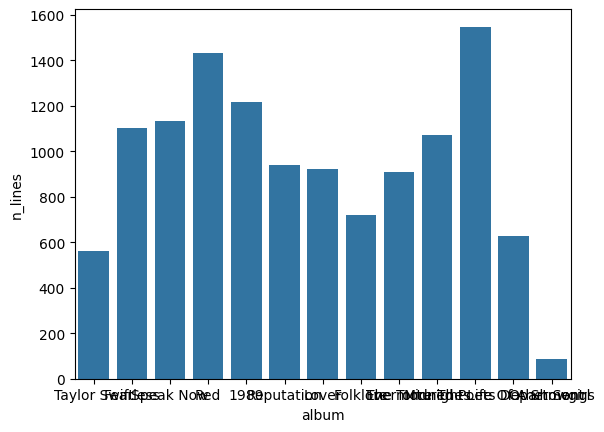

In [9]:
with open('../data/parsed_lyrics_sections.json', 'r') as f:
    album_order = json.load(f)['album_order']

plot_df = (
    lines_per_album
    .set_index('album_code')
    .loc[album_order]
    .reset_index()
)

sns.barplot(data=plot_df, x='album', y='n_lines')
plt.show()